## 1. Load the Data

In [11]:
import pandas as pd
import numpy as np

### Load the data
sensors = pd.read_csv("Sensors_M.csv")
sensors.head()

,Day,FactoryID,ProductLine,Shift,UnitsProduced,DefectiveUnits,DowntimeMinutes
0,1,F01,TempSensor,A,1235,92,14
1,1,F01,TempSensor,B,871,60,20
2,1,F01,TempSensor,C,560,82,22
3,1,F02,MotionSensor,B,1463,130,21
4,1,F02,TempSensor,A,1258,87,52


## 2. Check summary for errors

In [12]:
sensors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Day              270 non-null    int64 
 1   FactoryID        270 non-null    object
 2   ProductLine      270 non-null    object
 3   Shift            270 non-null    object
 4   UnitsProduced    270 non-null    int64 
 5   DefectiveUnits   270 non-null    int64 
 6   DowntimeMinutes  270 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 14.9+ KB


## 3. Total output of each factory

In [13]:
sensors.groupby(["FactoryID"])["UnitsProduced"].sum()


FactoryID
F01    100430
F02    102987
F03     99846
Name: UnitsProduced, dtype: int64

## 4. Total output by factory and sensor type

In [14]:
sensors.groupby(["FactoryID","ProductLine"])["UnitsProduced"].sum()

FactoryID  ProductLine 
F01        MotionSensor    50533
           TempSensor      49897
F02        MotionSensor    50073
           TempSensor      52914
F03        MotionSensor    53113
           TempSensor      46733
Name: UnitsProduced, dtype: int64

## 5. Highest avg output by shifts

In [15]:
sensors.groupby(["Shift"])["UnitsProduced"].mean().sort_values(ascending=False)

# Shift B has the highest avg production

Shift
B    1126.155556
C    1122.922222
A    1120.511111
Name: UnitsProduced, dtype: float64

## 6. Top 3 days with highest total defect counts

In [16]:
sensors.groupby(["Day"])["DefectiveUnits"].sum().sort_values(ascending=False).head(3)

# Day 17, 1, and 16 have the highest defect counts

Day
17    802
1     784
16    772
Name: DefectiveUnits, dtype: int64

## 7. Add variable of defect rate

In [17]:
sensors['DefectRate'] = (sensors['DefectiveUnits'] / sensors['UnitsProduced'])
sensors.head(10)

,Day,FactoryID,ProductLine,Shift,UnitsProduced,DefectiveUnits,DowntimeMinutes,DefectRate
0,1,F01,TempSensor,A,1235,92,14,0.074494
1,1,F01,TempSensor,B,871,60,20,0.068886
2,1,F01,TempSensor,C,560,82,22,0.146429
3,1,F02,MotionSensor,B,1463,130,21,0.088859
4,1,F02,TempSensor,A,1258,87,52,0.069157
5,1,F02,TempSensor,C,1143,107,29,0.093613
6,1,F03,MotionSensor,A,1185,63,59,0.053165
7,1,F03,MotionSensor,C,1052,88,48,0.083650
8,1,F03,TempSensor,B,960,75,57,0.078125
9,2,F01,MotionSensor,B,989,61,46,0.061678


## 8.Day-shift-factory combinations with defect rate > 10%

In [18]:
high = sensors[sensors["DefectRate"] > 0.1]
high[["Day", "Shift", "FactoryID", "DefectRate"]].drop_duplicates(subset=["Day", "Shift", "FactoryID"])


,Day,Shift,FactoryID,DefectRate
2,1,C,F01,0.146429
26,3,B,F03,0.108911
64,8,C,F01,0.107813
82,10,C,F01,0.122500
96,11,A,F03,0.100656
149,17,C,F02,0.133333
254,29,C,F01,0.101898
260,29,B,F03,0.106680


## 9. Make graph

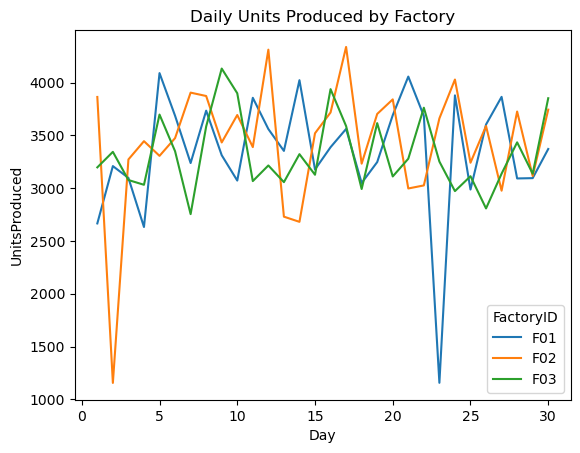

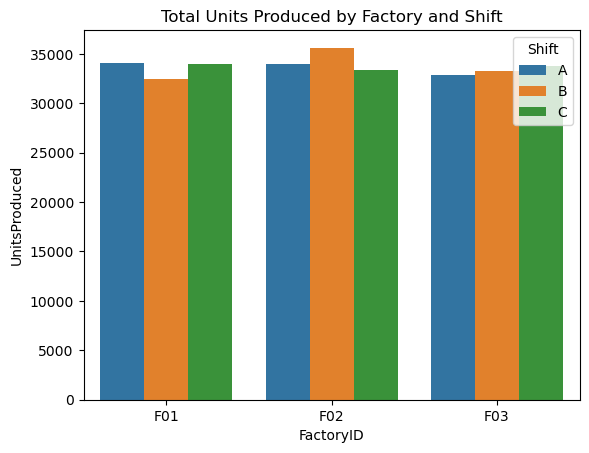

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# 9a) Daily units produced per factory
sns.lineplot(data=sensors, x="Day", y="UnitsProduced", hue="FactoryID", estimator="sum", errorbar=None)
plt.title("Daily Units Produced by Factory")
plt.show()

# 9b) Units produced by shift and factory
sns.barplot(data=sensors, x="FactoryID", y="UnitsProduced", hue="Shift", estimator="sum", errorbar=None)
plt.title("Total Units Produced by Factory and Shift")
plt.show()


In [20]:
## 10 a) average of the individual DefectRate values
avg_rate = sensors.groupby(['FactoryID'])['DefectRate'].mean()

avg_rate.head(3)

FactoryID
F01    0.047464
F02    0.048709
F03    0.049831
Name: DefectRate, dtype: float64

In [21]:
## 10 b) total defective units / total units produced
totals = sensors.groupby(['FactoryID'])[['DefectiveUnits', 'UnitsProduced']].sum()
pooled_rate = totals['DefectiveUnits'] / totals['UnitsProduced']

pooled_rate.head(3)

FactoryID
F01    0.048641
F02    0.050754
F03    0.049546
dtype: float64

## Difference ##
Part 10a computes the simple/unweighted mean of each row's own defect rate, while part 10b \sums all DefectiveUnits and all UnitsProduced across each factory first and only then divides, which weights each unit by production volume rather than each batch equally; since factories don't produce exactly the same number of units in every batch, these two produce different numbers. 
## Defensible Method ##
The pooled version (10b) is more defensible because it reflects the true aggregate rate,rather than letting small, low-volume batches sway the average as much as large ones.


## 11. Synthesis ##

In [22]:
# Build one summary table per Factory x Shift: output, pooled defect rate, downtime intensity
summary = sensors.groupby(["FactoryID", "Shift"]).agg(
    UnitsProduced=("UnitsProduced", "sum"),
    DefectiveUnits=("DefectiveUnits", "sum"),
    DowntimeMinutes=("DowntimeMinutes", "sum")
)
summary["DefectRate"] = summary["DefectiveUnits"] / summary["UnitsProduced"]
summary["DowntimePer1000Units"] = summary["DowntimeMinutes"] / summary["UnitsProduced"] * 1000
summary = summary.sort_values("DefectRate", ascending=False)
summary

UnitsProduced  DefectiveUnits  DowntimeMinutes  DefectRate  \
FactoryID Shift                                                               
F02       C              33386            1802              981    0.053975   
          A              33984            1822              667    0.053613   
F01       C              33947            1775              923    0.052287   
F03       C              33730            1758              969    0.052120   
          B              33285            1650             1080    0.049572   
F01       A              34031            1603              901    0.047104   
F03       A              32831            1539             1058    0.046876   
F01       B              32452            1507              853    0.046438   
F02       B              35617            1603              907    0.045007   

                 DowntimePer1000Units  
FactoryID Shift                        
F02       C                 29.383574  
          A                 19.626883  
F01       C                 27.189442  
F03       C                 28.728135  
          B                 32.447048  
F01       A                 26.475860  
F03       A                 32.225640  
F01       B                 26.284975  
F02       B                 25.465368

**Underperformer: Factory F02, Shift C** 

- **Highest defect rate overall.** F02-C's pooled defect rate is 5.40%, the worst of all nine Factory×Shift groups.
- **It's also home to the single worst day in the whole dataset.** Day 17 was one of the top-3 days for total defects (section 6), and the day-level breakdown in section 8 shows that spike was F02, Shift C, at a 13.3% defect rate.
- **Downtime backs it up.** At 29.4 minutes of downtime per 1,000 units produced, F02-C has the second-highest downtime intensity of all nine groups.


